# Checkpoint 3

Júlia Ferreira França rm 563445

Guilherme Moraes de Sousa rm 563530

## Imports

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, precision_score
from sklearn.model_selection import GridSearchCV

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
path = "/content/drive/MyDrive/Dados"

In [64]:
features = pd.read_csv(path + "/sv_features_adicionais.csv", parse_dates=['data_adesao', 'data_cancelamento'])
clientes = pd.read_csv(path + "/sv_clientes.csv", parse_dates=['data_adesao', 'data_cancelamento'])
pagamentos = pd.read_csv(path + "/sv_pagamentos.csv", parse_dates=['data_pagamento'])
consumo = pd.read_csv(path + "/sv_consumo.csv", parse_dates=['data_consumo'])
marketing_atr = pd.read_csv(path + "/sv_marketing_atribuicao.csv")
marketing_inv = pd.read_csv(path + "/sv_marketing_investimento.csv")
devices = pd.read_csv(path + "/sv_devices.csv")
consumo_detalhado = pd.read_csv(path + "/sv_consumo_detalhado.csv", parse_dates=['data_consumo'])
data_fim = consumo_detalhado["data_consumo"].max()

In [65]:
var_target = 'churn'

## 1 - Feature Engeneering
Faça a etapa de feature engineering dos dados e justifique as transformações aplicadas

In [66]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   cliente_id                 1500 non-null   int64         
 1   data_adesao                1500 non-null   datetime64[ns]
 2   data_cancelamento          296 non-null    datetime64[ns]
 3   plano                      1500 non-null   object        
 4   idade                      1500 non-null   float64       
 5   renda_mensal               1500 non-null   float64       
 6   churn                      1500 non-null   int64         
 7   data_fim                   1500 non-null   object        
 8   tenure_dias                1500 non-null   int64         
 9   total_pago                 1500 non-null   float64       
 10  ticket_medio               1500 non-null   float64       
 11  num_pagamentos             1500 non-null   int64         
 12  total_

### Procurando Inconsistências
Nessa etapa:
 - Tratamento de inconsistências na coluna renda_mensal (valores negativos)
 - Tratamento de inconsistências na coluna idade (idade negativa e clientes novos demais)
 - Identificação de Nulos

In [67]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cliente_id         1500 non-null   int64         
 1   data_adesao        1500 non-null   datetime64[ns]
 2   data_cancelamento  296 non-null    datetime64[ns]
 3   plano              1500 non-null   object        
 4   idade              1452 non-null   float64       
 5   renda_mensal       1500 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(1)
memory usage: 70.4+ KB


In [68]:
clientes['idade'].describe()

,idade
count,1452.000000
mean,34.431129
std,10.155311
min,-1.000000
25%,27.000000
50%,34.000000
75%,41.000000
max,69.000000


In [69]:
features['idade'].describe()

,idade
count,1500.000000
mean,33.329333
std,11.686513
min,-1.000000
25%,26.000000
50%,34.000000
75%,41.000000
max,69.000000


In [70]:
nulos_original = clientes.loc[clientes['idade'].isna(), 'cliente_id']

print(f"Total de IDs com idade nula: {len(nulos_original)}")

Total de IDs com idade nula: 48


In [71]:
investigacao = features[features['cliente_id'].isin(nulos_original)]
print(f"Total de registros para investigação: {len(investigacao)}")
investigacao['idade'].describe()

Total de registros para investigação: 48


,idade
count,48.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [72]:
clientes_idade_inconsistency = features.loc[features['idade'] < 0, 'idade'].count()
print(f"Quantidade de clientes com idade negativa: {clientes_idade_inconsistency} ({(clientes_idade_inconsistency/(len(features))) * 100:.2f}%)")

Quantidade de clientes com idade negativa: 1 (0.07%)


In [73]:
clientes_bebes = features.loc[features['idade'] <= 2, 'idade'].count()
print(f"Quantidade de clientes com 2 anos ou mais: {clientes_bebes} ({(clientes_bebes/(len(features))) * 100:.2f}%)")

Quantidade de clientes com 2 anos ou mais: 49 (3.27%)


In [74]:
clientes_novos_demais = features.loc[features['idade'] <= 12, 'idade'].count()
print(f"Quantidade de clientes com 12 anos ou menos: {clientes_novos_demais} ({(clientes_novos_demais/(len(features))) * 100:.2f}%)")

Quantidade de clientes com 12 anos ou menos: 66 (4.40%)


In [75]:
features['renda_mensal'].describe()

,renda_mensal
count,1500.000000
mean,4393.027727
std,2075.310416
min,-2276.860000
25%,2939.825000
50%,4380.880000
75%,5861.702500
max,11698.930000


In [76]:
# Tratamento renda_mensal
renda_mensal_negativa = features.loc[features['renda_mensal'] < 0, 'renda_mensal']
n_renda_mensal_negativa = len(renda_mensal_negativa)
print(f"Quantidade de clientes com renda negativa: {n_renda_mensal_negativa} ({(n_renda_mensal_negativa/(len(features))) * 100:.2f}%)")

Quantidade de clientes com renda negativa: 24 (1.60%)


In [77]:
renda_mensal_negativa.describe()

,renda_mensal
count,24.000000
mean,-766.038333
std,674.699557
min,-2276.860000
25%,-1205.067500
50%,-586.815000
75%,-273.217500
max,-27.460000


In [78]:
# Tratamento escolhido: renda_mensal_negativa - multilicar por -1
features['renda_mensal'] = features['renda_mensal'].apply(lambda x: x * -1 if x < 0 else x)
features['renda_mensal'].describe()

,renda_mensal
count,1500.000000
mean,4417.540953
std,2022.571081
min,8.660000
25%,2939.825000
50%,4380.880000
75%,5861.702500
max,11698.930000


In [79]:
# Tratamento escolhido: preencher todos os novos demais com valores médios dos grupos por renda_mensal

features['quartil_renda'] = pd.qcut(features['renda_mensal'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

renda_mensal_media = features[features['idade'] > 12].groupby('quartil_renda')['idade'].mean().round().astype(int)

def corrigir_idade(row):
    if row['idade'] <= 12 or pd.isna(row['idade']):
        return renda_mensal_media.get(row['quartil_renda'], features['idade'].mean())
    return row['idade']

features['idade'] = features.apply(corrigir_idade, axis=1)

restantes = (features['idade'] <= 12).sum()
print(f"Registros com idade <= 12 após o tratamento: {restantes}")

Registros com idade <= 12 após o tratamento: 0


/tmp/ipykernel_10159/2653720991.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  renda_mensal_media = features[features['idade'] > 12].groupby('quartil_renda')['idade'].mean().round().astype(int)


In [80]:
# Testando se o df possui nulls
df_numerico_total = features.select_dtypes(include=['int64', 'float64'])
df_numerico_total = df_numerico_total.set_index('cliente_id')
num_columns = len(df_numerico_total.columns) - 1 #(churn)
nulls = df_numerico_total.isnull().sum()
nulls[nulls > 0]

,0


### Ordinal Encoding

In [81]:
# Criando coluna plano ordinal
mapeamento = {'Basic': 1, 'Standard': 2, 'Premium': 3}
features['plano_ordinal'] = features['plano'].map(mapeamento)

### Selecionando e Padronizando
Nessa etapa:
- Elimando colunas pela correlacão entre si
- Avaliando features pela correlação com churn
- Avaliando features por Embedded Process


In [82]:
# Removendo Features altamente correlacionadas - Redundância
metodo = 'pearson'
df_features_com_redundancia = df_numerico_total.drop(columns=[var_target])
corr_matrix = df_features_com_redundancia.corr(method=metodo).abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

lista_pares = []
for col in upper.columns:
    correlacionadas = upper.index[upper[col] > 0.8].tolist()
    for row in correlacionadas:
        lista_pares.append({
            'Variavel_1': row,
            'Variavel_2': col,
            'Correlacao': upper.loc[row, col]
        })

df_redundancia = pd.DataFrame(lista_pares).sort_values(by='Correlacao', ascending=False)

print(f"{'='*60}")
print(f"ANÁLISE DE REDUNDÂNCIA (Método: {metodo.upper()})")
print(f"{'='*60}")

if not df_redundancia.empty:
    print("Pares com alta correlação encontrados (Ordenados do maior para o menor):")
    print(df_redundancia.to_string(index=False, formatters={'Correlacao': '{:,.4f}'.format}))
else:
    print("Nenhuma correlação acima de 0.8 encontrada.")

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
df_features_sem_redundancia = df_numerico_total.drop(columns=to_drop)

print(f"\n{'='*60}")
print("RESULTADO DA REDUÇÃO")
print(f"{'='*60}")
print(f"Variáveis originais: {len(df_features_com_redundancia.columns)}")
print(f"Variáveis removidas: {len(to_drop)}")
print(f"Variáveis finais:    {len(df_features_sem_redundancia.columns) - 1} (excluindo target)")
print(f"Variaveis que foram removidas: {', '.join(to_drop)}")
print(f"{'='*60}")

ANÁLISE DE REDUNDÂNCIA (Método: PEARSON)
Pares com alta correlação encontrados (Ordenados do maior para o menor):
           Variavel_1            Variavel_2 Correlacao
        media_minutos  minutos_por_conteudo     1.0000
         media_rating            max_rating     0.9988
    categorias_unicas            max_rating     0.9973
    categorias_unicas          media_rating     0.9967
         media_rating     engajamento_score     0.9929
     media_completion          media_rating     0.9922
           max_rating     engajamento_score     0.9906
     media_completion       rating_alta_pct     0.9904
    categorias_unicas     engajamento_score     0.9902
           std_rating            max_rating     0.9899
        total_minutos       total_conteudos     0.9898
     media_completion     engajamento_score     0.9880
      total_conteudos          taxa_rewatch     0.9872
     media_completion            max_rating     0.9864
         media_rating            std_rating     0.9862
    ca

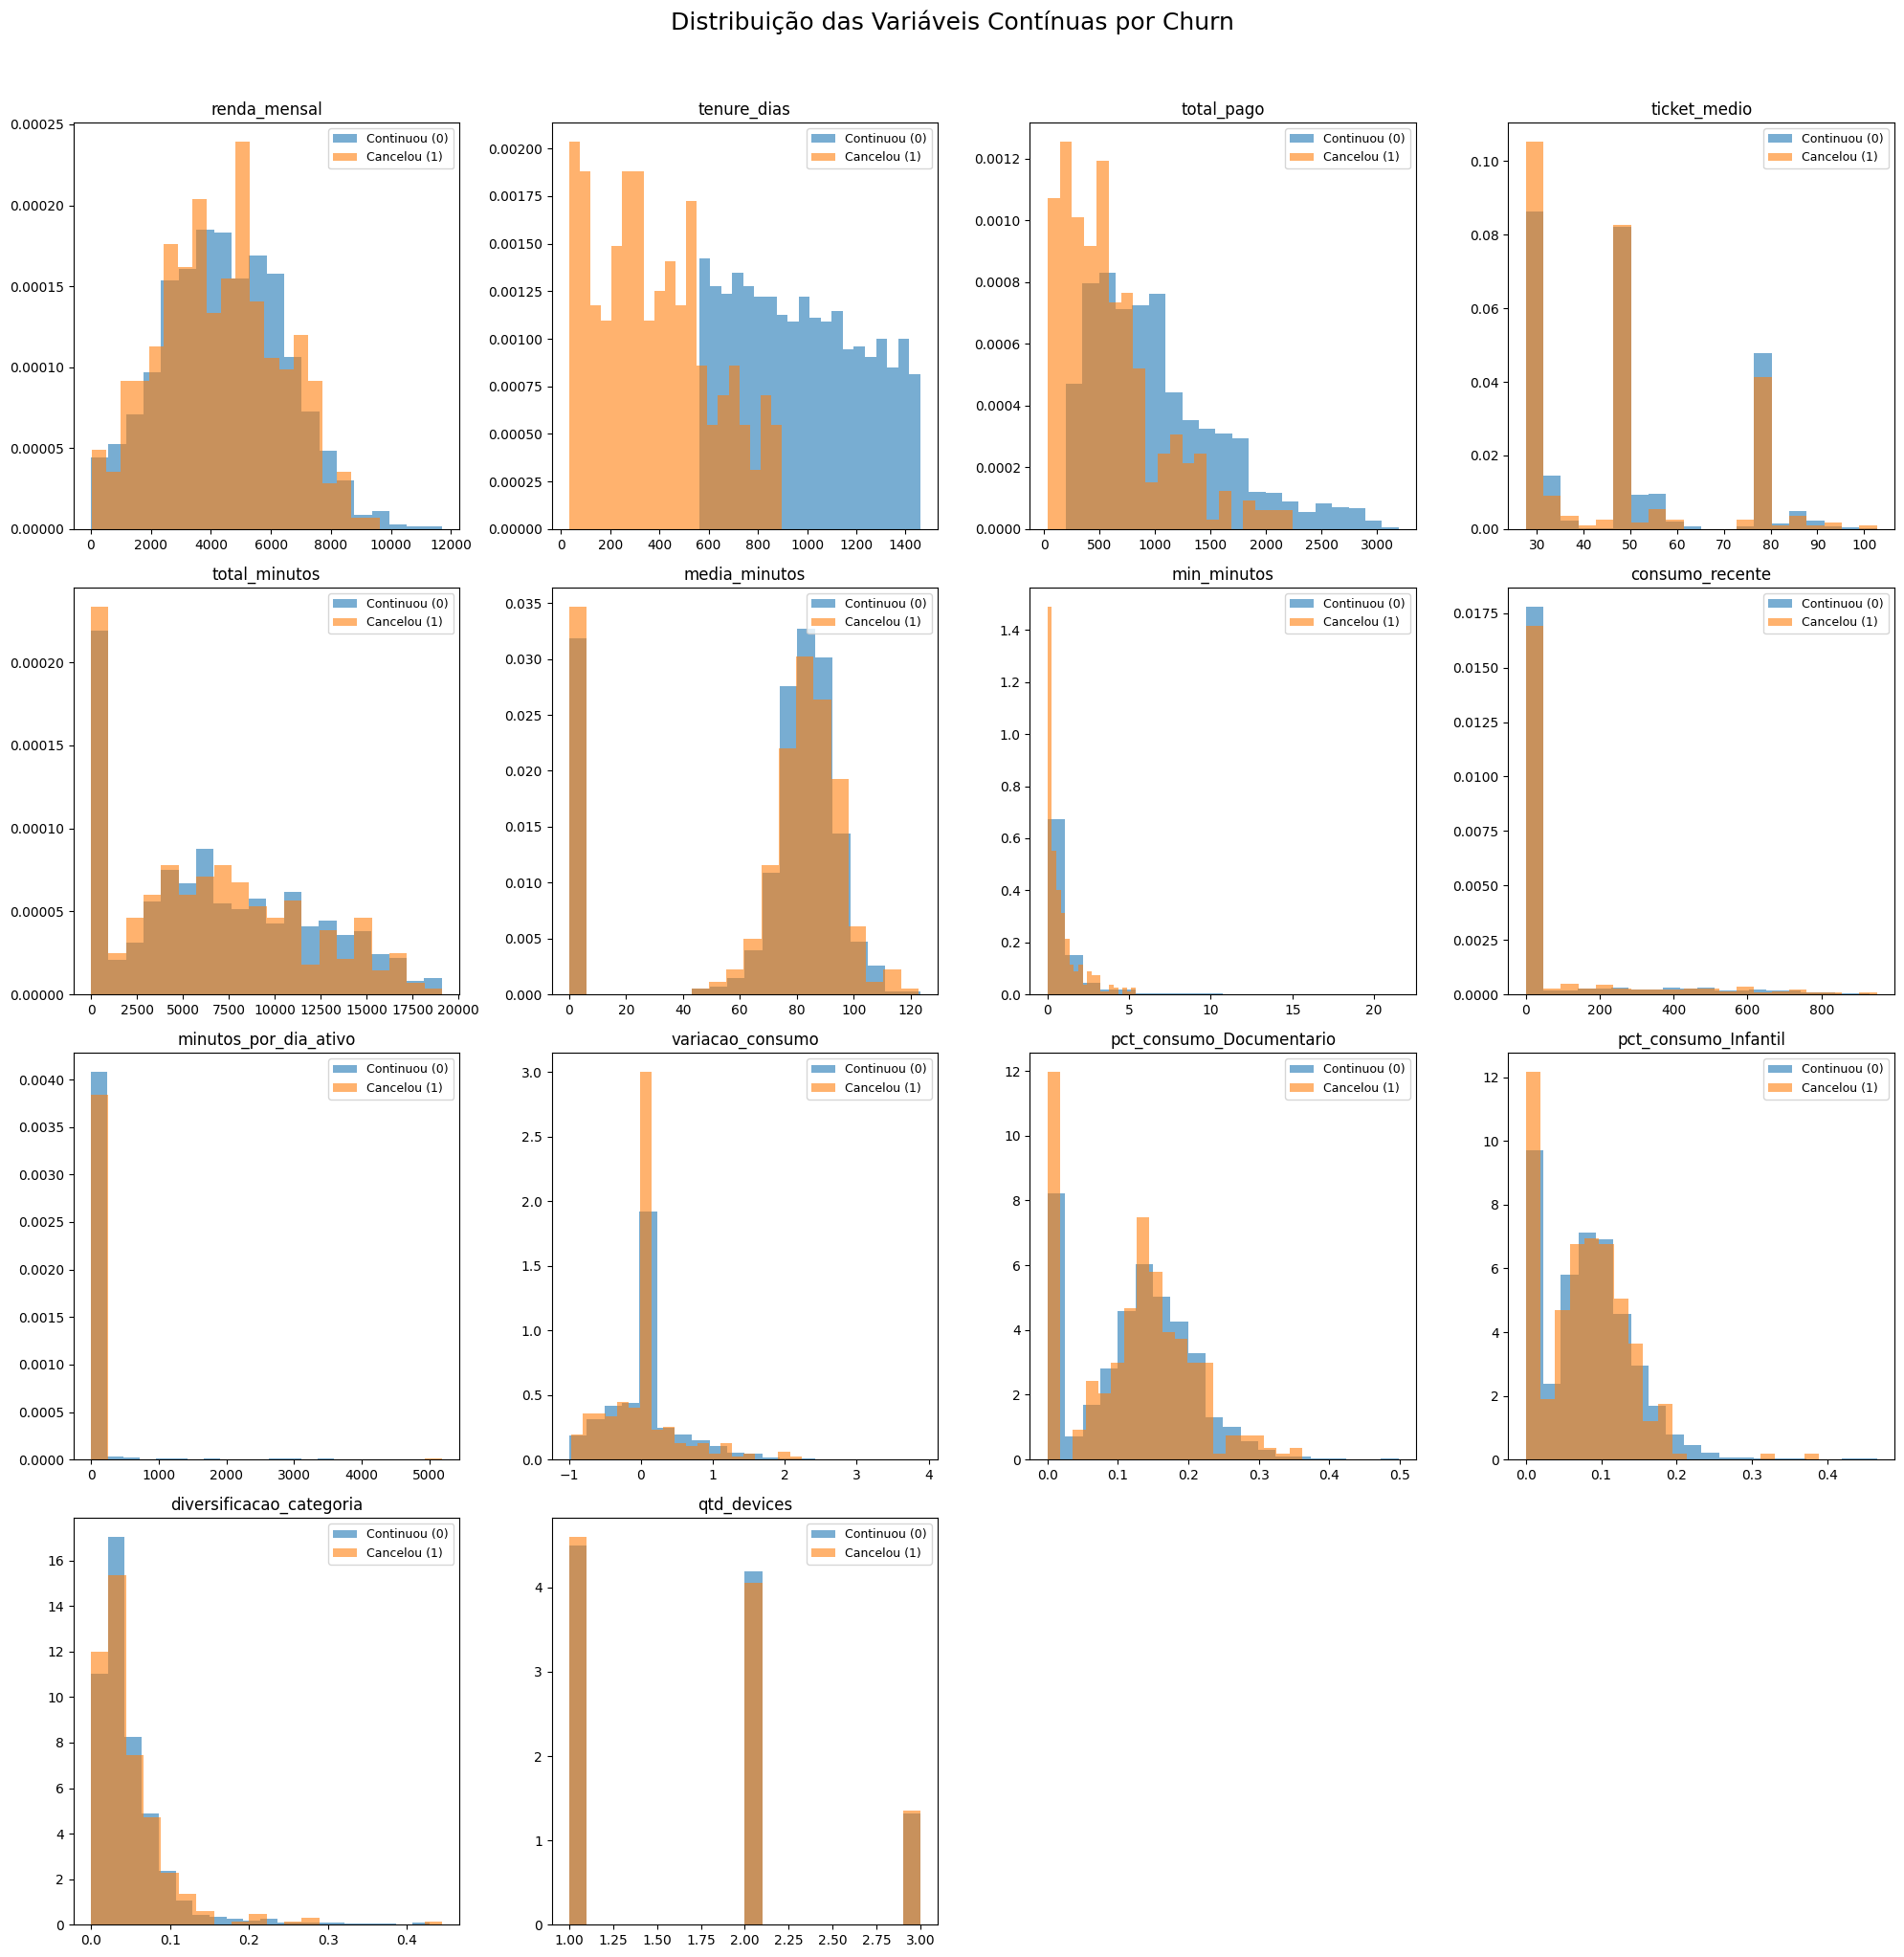

In [83]:
colunas_continuas = [
    'renda_mensal', 'tenure_dias', 'total_pago', 'ticket_medio',
    'total_minutos', 'media_minutos', 'min_minutos', 'consumo_recente',
    'minutos_por_dia_ativo', 'variacao_consumo', 'pct_consumo_Documentario',
    'pct_consumo_Infantil', 'diversificacao_categoria', 'qtd_devices'
]

n = len(colunas_continuas)
n_cols = 4 # Quantidade de gráficos por linha
n_rows = math.ceil(n / n_cols)

# Cria a figura com o tamanho dinâmico (cresce conforme o número de linhas)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))

# Transforma a matriz de gráficos em uma lista plana para facilitar o loop
axes = axes.flatten()

for i, col in enumerate(colunas_continuas):
    ax = axes[i]

    # 0 = Continuou a assinar | 1 = Parou de assinar (Churn)
    for label, label_name in zip([0, 1], ['Continuou (0)', 'Cancelou (1)']):

        # Filtra os dados e remove nulos
        subset = features[features[var_target] == label][col].dropna()

        # Gera o histograma sobreposto
        ax.hist(subset, bins=20, alpha=0.6, label=label_name, density=True)

    ax.set_title(col, fontsize=12) # Coloca o nome da variável no topo
    ax.legend(fontsize=9)

# Ocultar os "quadrados" vazios que sobrarem no final do grid
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuição das Variáveis Contínuas por Churn', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

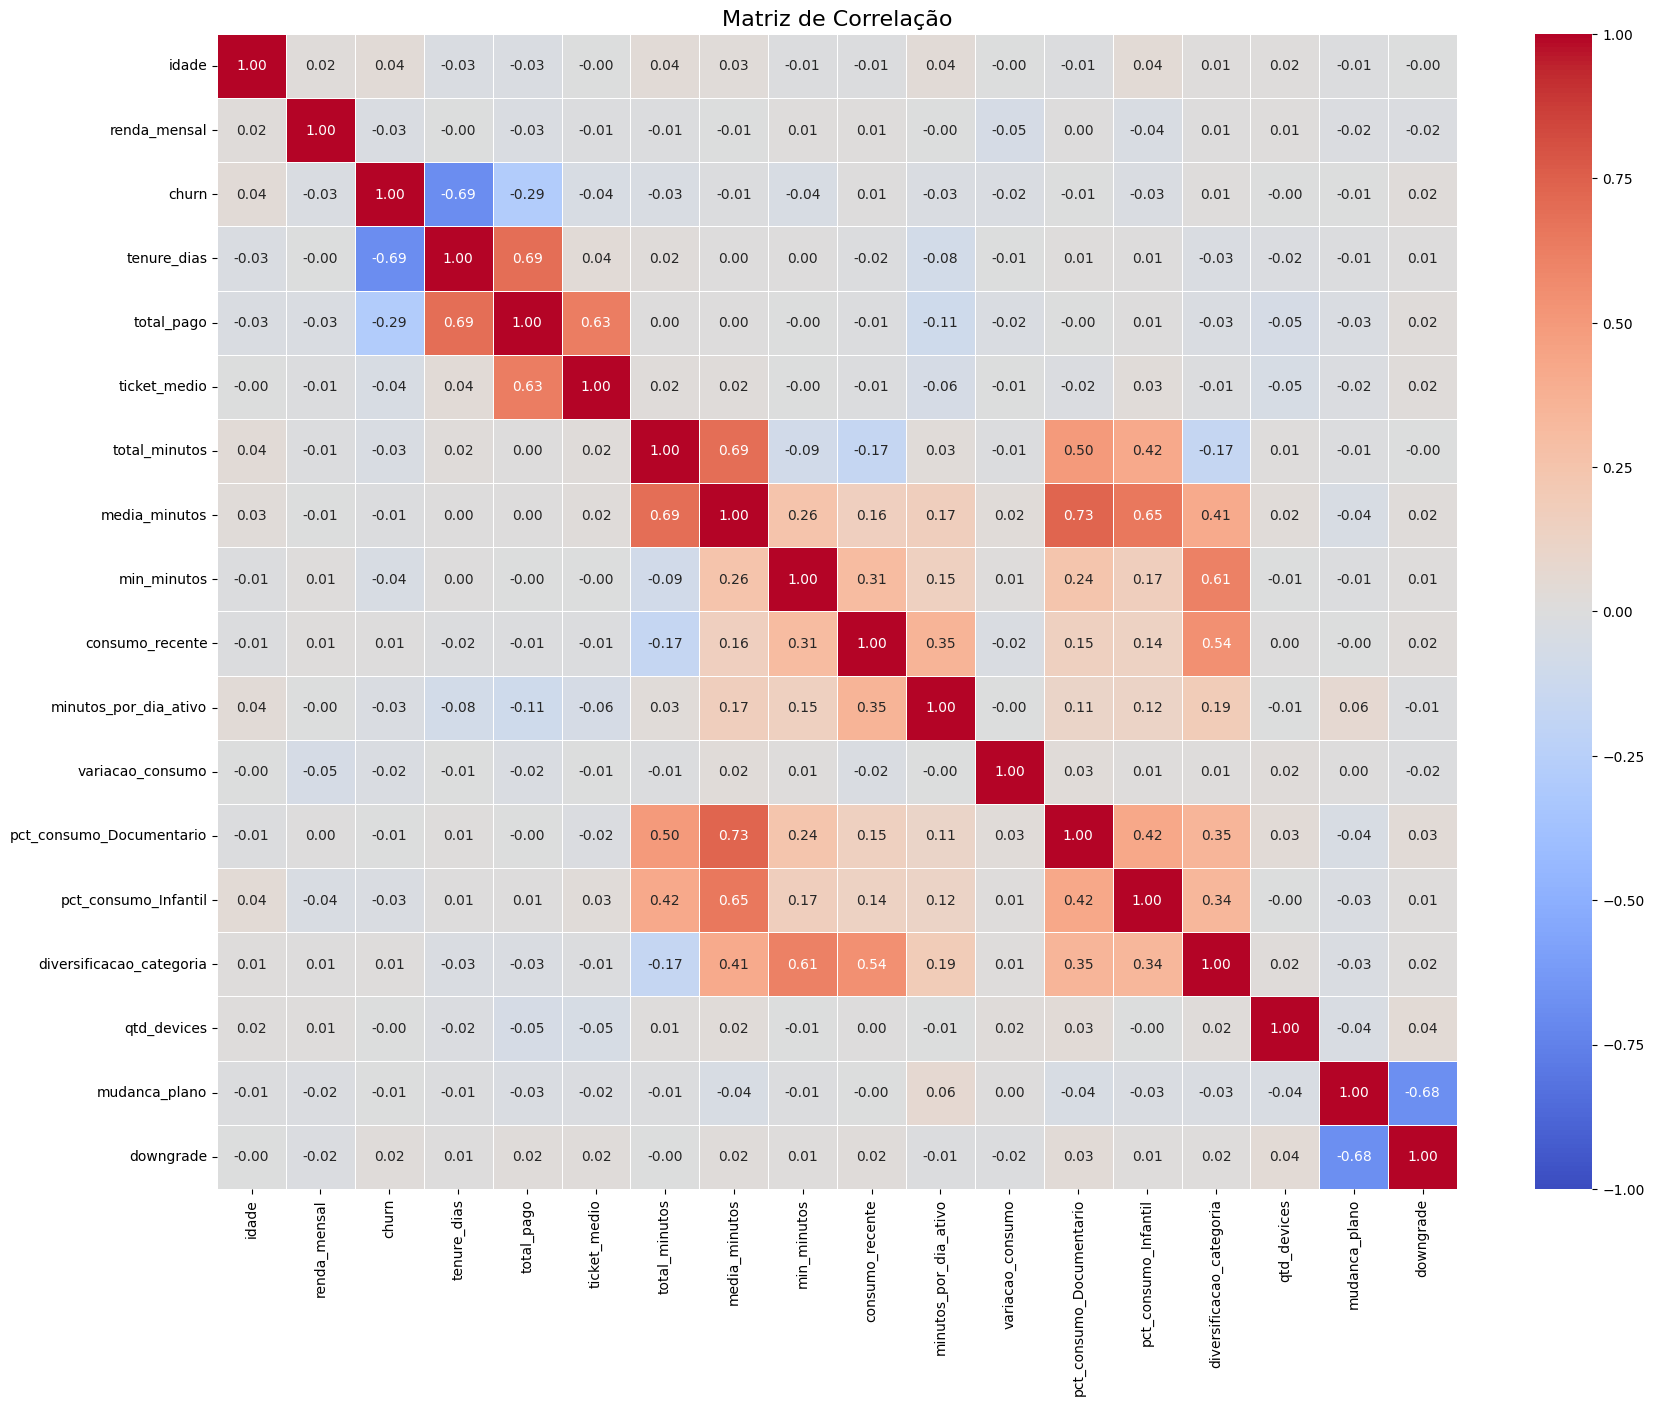

In [84]:
# Correlação de todas as variáveis
matriz_corr = df_features_sem_redundancia.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=16)
plt.show()

In [85]:
# Eliminando a coluna mudanca_plano - downgrade é melhor
df_features_sem_redundancia = df_features_sem_redundancia.drop(columns=['mudanca_plano'])

In [86]:
# Padronização
scaler = StandardScaler()

df_features_sem_redundancia[colunas_continuas] = scaler.fit_transform(df_features_sem_redundancia[colunas_continuas])

In [87]:
# Separação dados de treino e teste para Embedded Method
X = df_features_sem_redundancia.drop([var_target], axis=1) # Armazena todas as variáveis menos a variável alvo
y = df_features_sem_redundancia[var_target] # armazena apenas a variável alvo

# Dividindo entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


MODELO: XGBClassifier
Acurácia:  0.9933
Recall:    0.9833
F1 Score:  0.9833
Precision: 0.9833


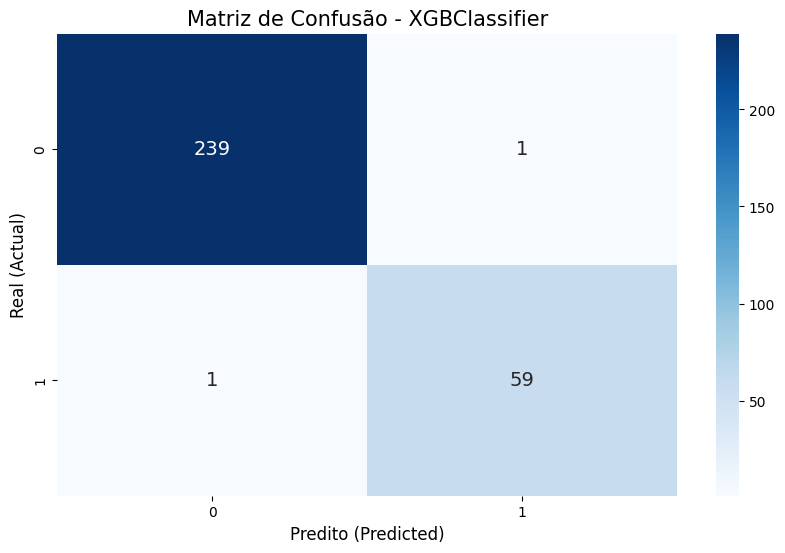

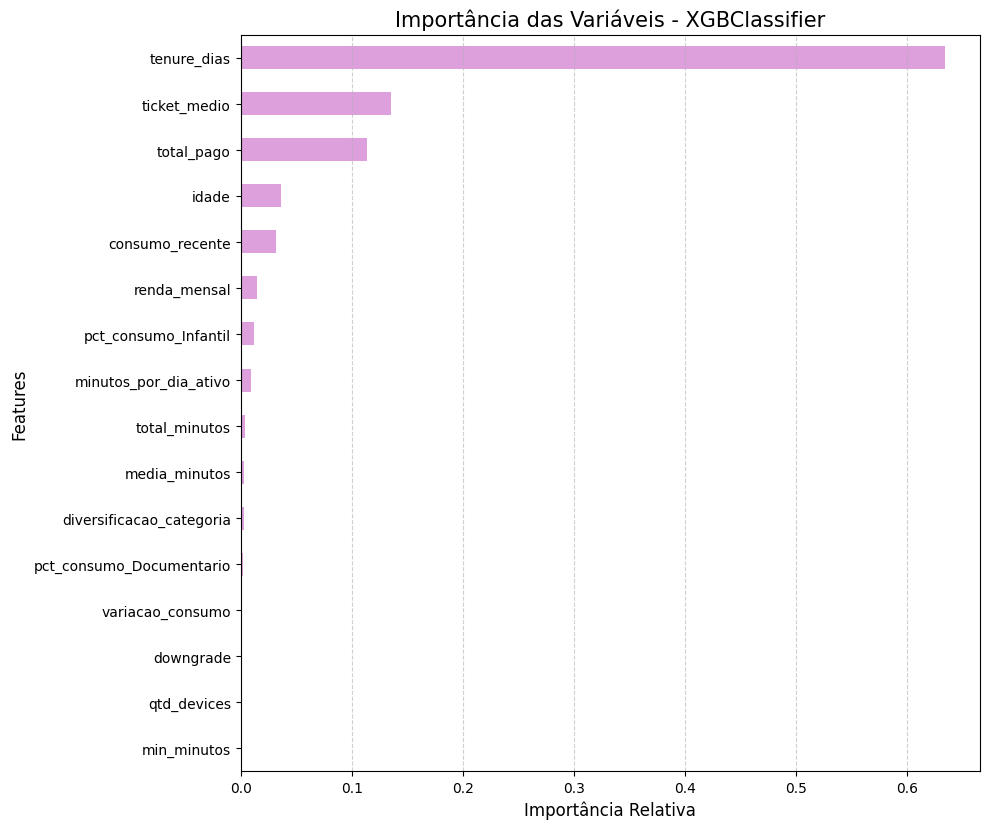

In [88]:
# Treinando XGBClassifier com todas as variáveis e verificando a feature importance de cada
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
model_name = xgb.__class__.__name__

print(f'\n' + '='*30)
print(f'MODELO: {model_name}')
print(f'='*30)
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")

# --- GRÁFICO 1: Matriz de Confusão ---
plt.figure(figsize=(10, 6)) # Tamanho maior para visibilidade
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14})

plt.title(f'Matriz de Confusão - {model_name}', fontsize=15)
plt.xlabel('Predito (Predicted)', fontsize=12)
plt.ylabel('Real (Actual)', fontsize=12)
plt.show()

# --- GRÁFICO 2: Feature Importance (Todas as Features) ---
importances = xgb.feature_importances_

feat_importances = pd.Series(importances, index=X_train.columns)

# Ajustamos a altura da figura baseada no número de features (para não amontoar)
plt.figure(figsize=(10, len(X_train.columns) * 0.4 + 2))

feat_importances.sort_values(ascending=True).plot(kind='barh', color='plum')

plt.title(f'Importância das Variáveis - {model_name}', fontsize=15)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [89]:
# Seleção de Features
df_features_sem_redundancia = df_features_sem_redundancia.drop(["variacao_consumo", "downgrade", "qtd_devices", "min_minutos"], axis=1)

# Separação dados de treino e teste para Embedded Method
X = df_features_sem_redundancia.drop([var_target], axis=1) # Armazena todas as variáveis menos a variável alvo
y = df_features_sem_redundancia[var_target] # armazena apenas a variável alvo

# Dividindo entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

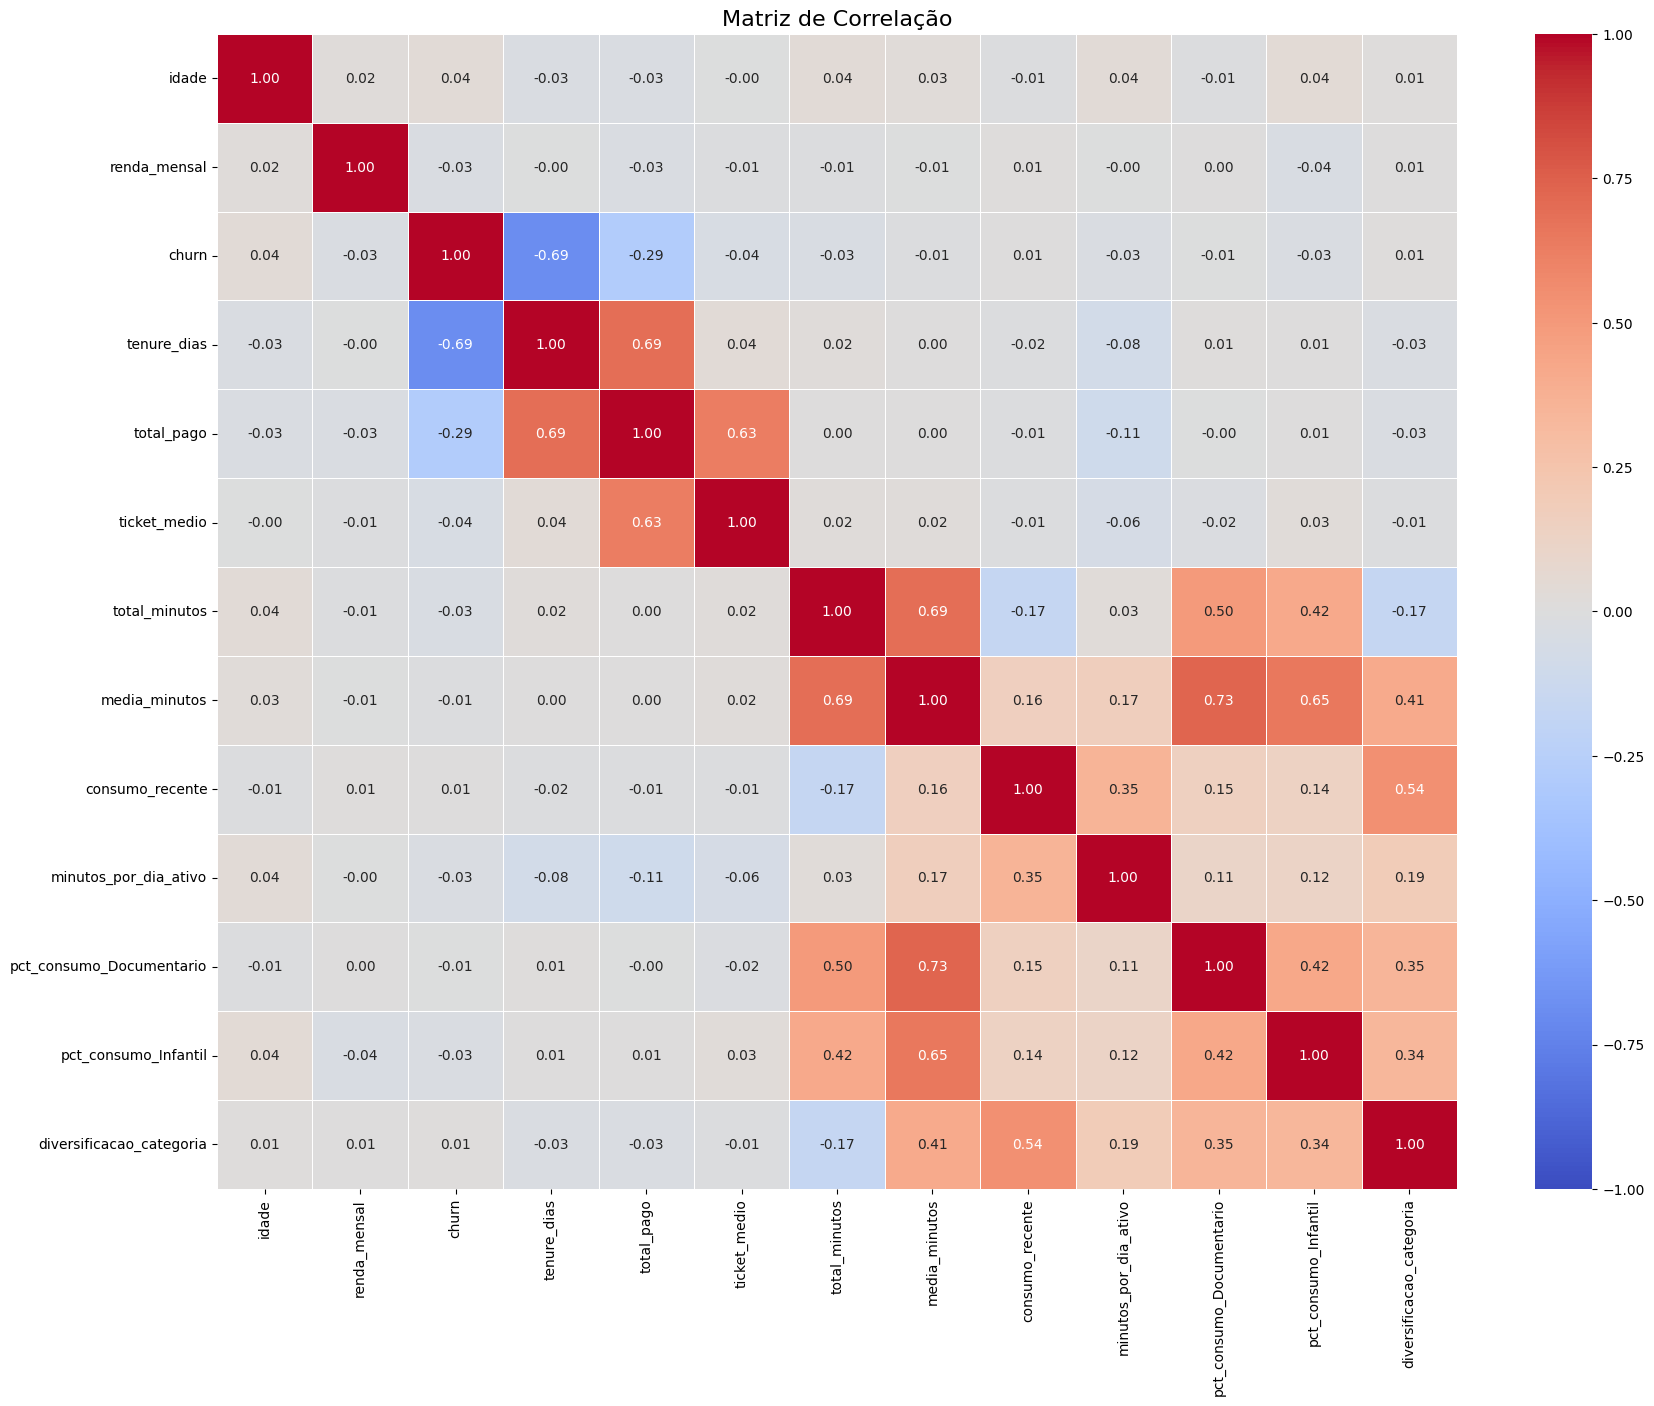

In [90]:
# Correlação de todas as variáveis
matriz_corr = df_features_sem_redundancia.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=16)
plt.show()

### Explicação completa item 1 - Feature engeneering

O dataset features continha alguns valores anômalos, como clientes recém nascidos e renda mensal negativa. Dado esse comportamento, foi feito um tratamento. Para a renda negativa, foi feita a multiplicação por -1. Para as idades menores que 12 anos, foi feita uma substituição de forma estratificada, usando a média do grupo de renda (4 quartis). Também foi adicionada uma feature chamada plano ordinal (os planos organizados de pior a melhor, com números).

Feitas essas transformações, partimos para a seleção de features. Foi feita a exclusão de todas as features com correlação absoluta maior que 0.8. No caso, ficou apenas as colunas não redundantes. Depois disso foi feita mais uma limpa utilizando o Embedded Method, que é um método de seleção de features que identifica padrões não lineares. Para tal, usamos o XGBoostClassifier, com todas as features. Eliminamos as que não fizeram diferença alguma no resultado final.

## 2 - Treinamento

Treine ao menos um modelo de base, inicial para criação de baseline e comparação da evolução, comente a escolha e o resultado até o momento

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



MODELO: LogisticRegression
Acurácia:  0.9900
Recall:    0.9500
F1 Score:  0.9744
Precision: 1.0000


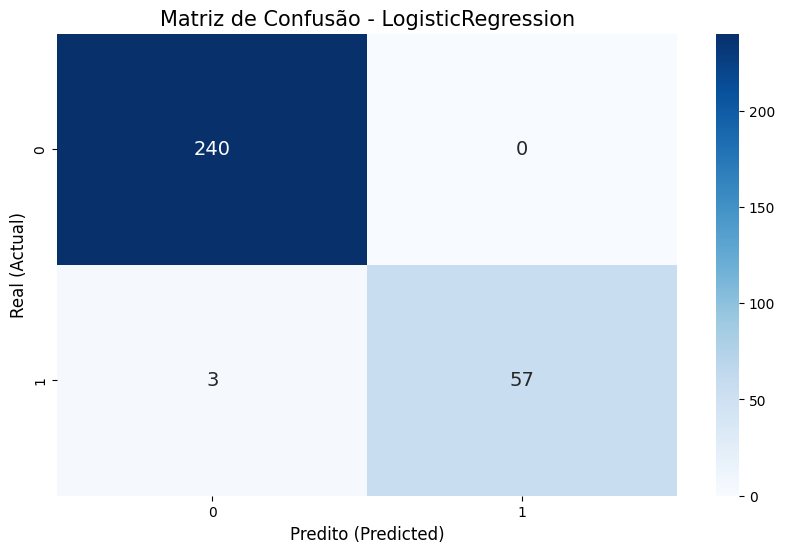

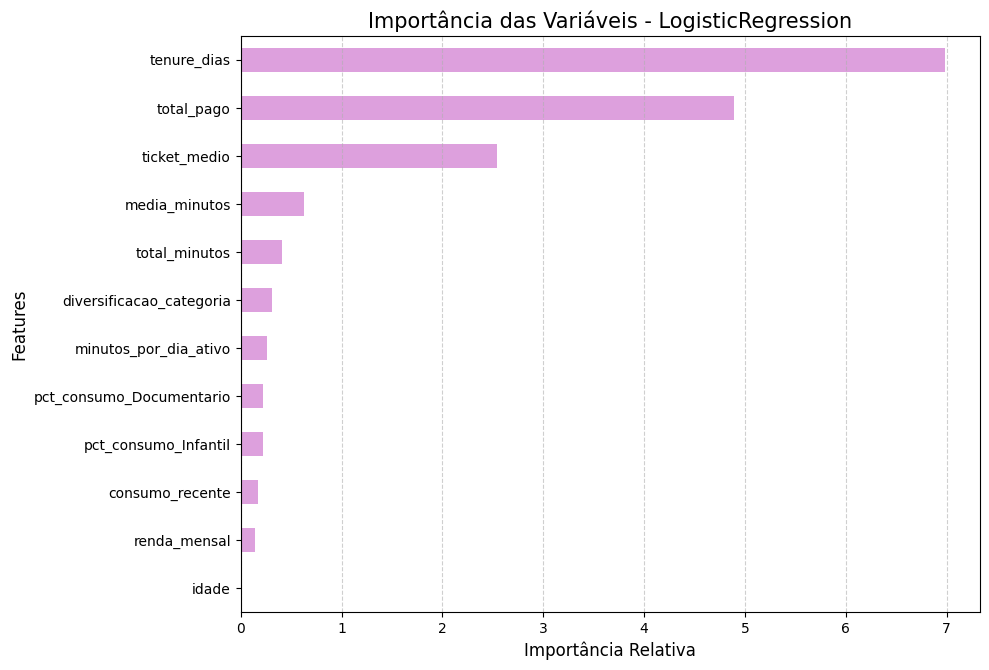


MODELO: DecisionTreeClassifier
Acurácia:  0.9967
Recall:    1.0000
F1 Score:  0.9917
Precision: 0.9836


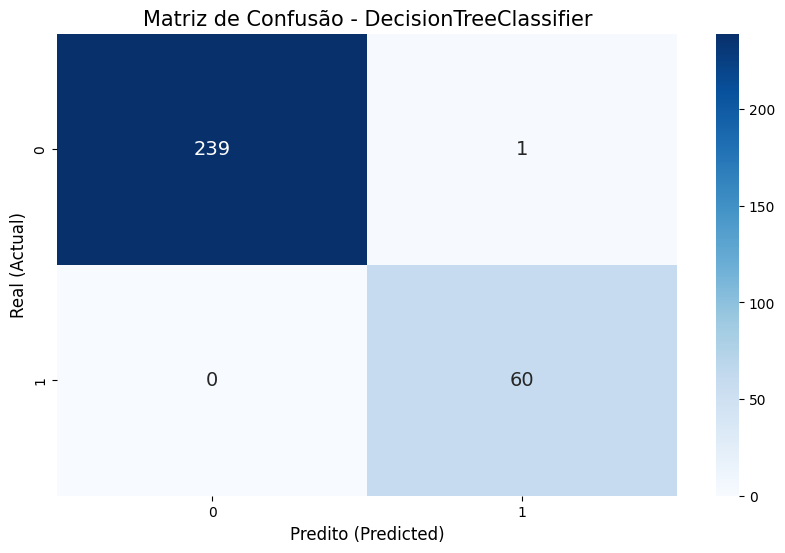

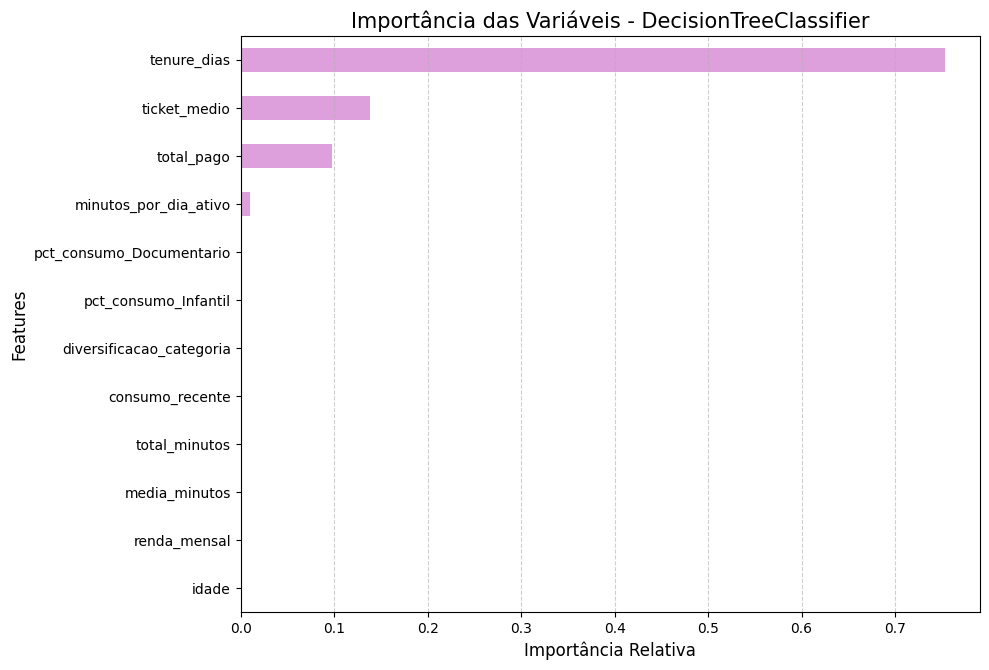


MODELO: RandomForestClassifier
Acurácia:  0.9767
Recall:    0.8833
F1 Score:  0.9381
Precision: 1.0000


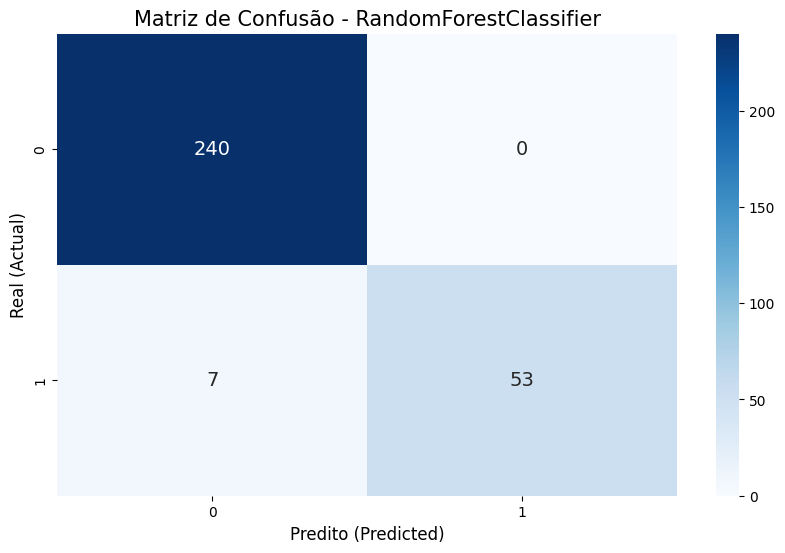

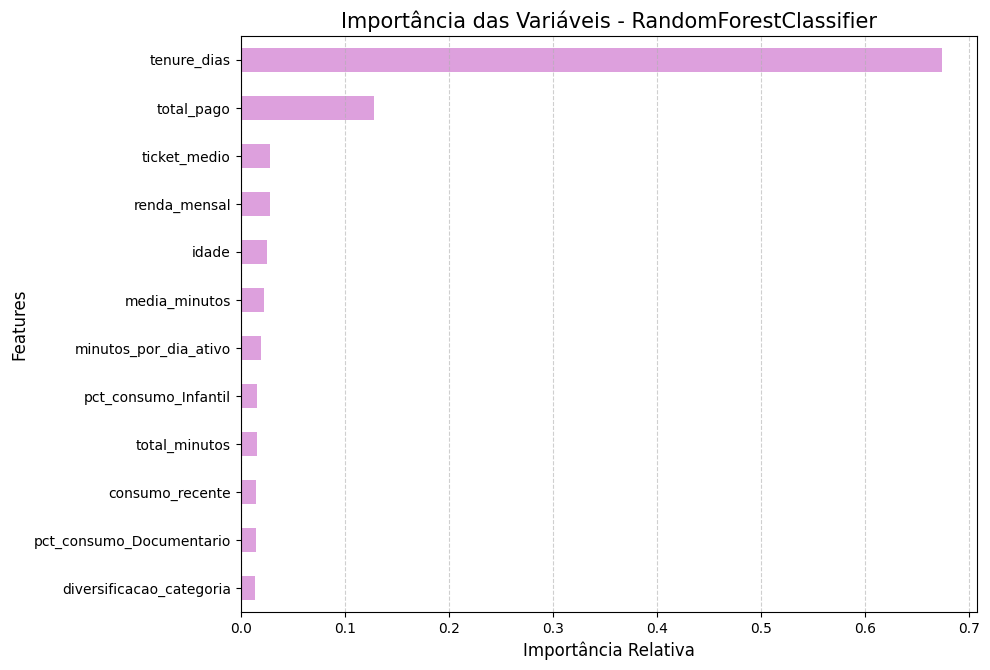


MODELO: KNeighborsClassifier
Acurácia:  0.8600
Recall:    0.4333
F1 Score:  0.5532
Precision: 0.7647


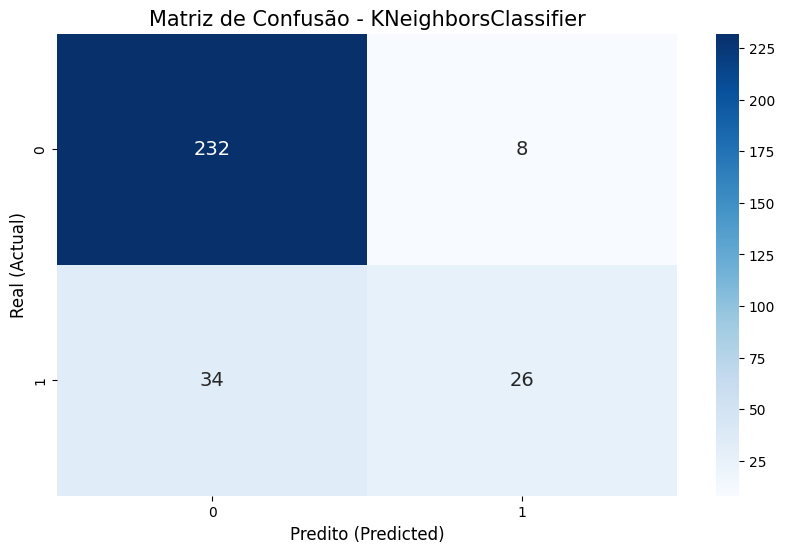

Nota: O modelo KNeighborsClassifier não possui cálculo nativo de importância de features.

MODELO: GaussianNB
Acurácia:  0.9100
Recall:    0.8500
F1 Score:  0.7907
Precision: 0.7391


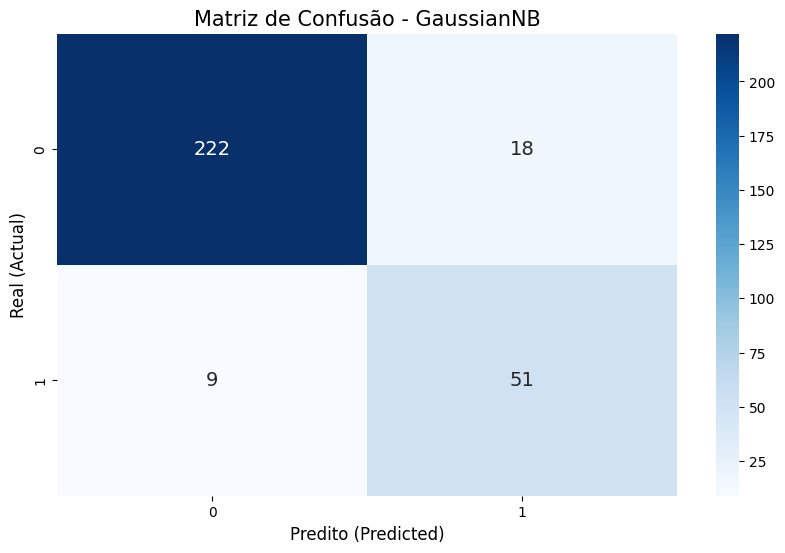

Nota: O modelo GaussianNB não possui cálculo nativo de importância de features.

MODELO: SGDClassifier
Acurácia:  0.9833
Recall:    0.9167
F1 Score:  0.9565
Precision: 1.0000


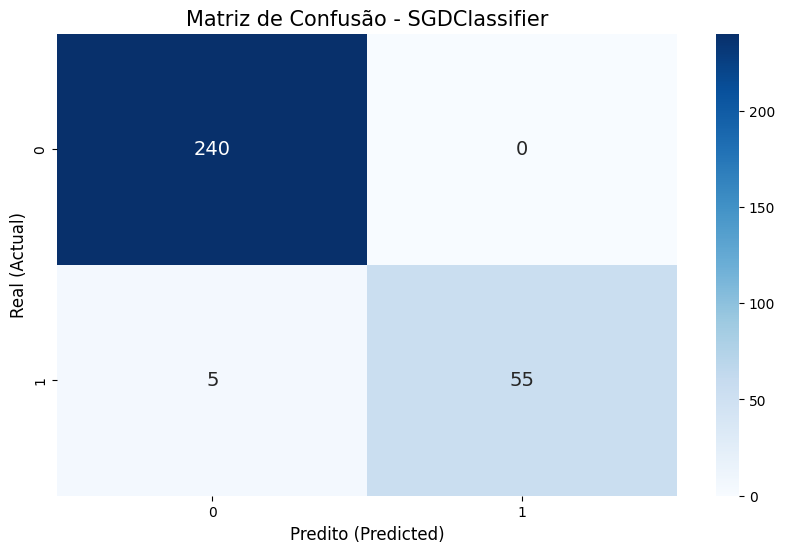

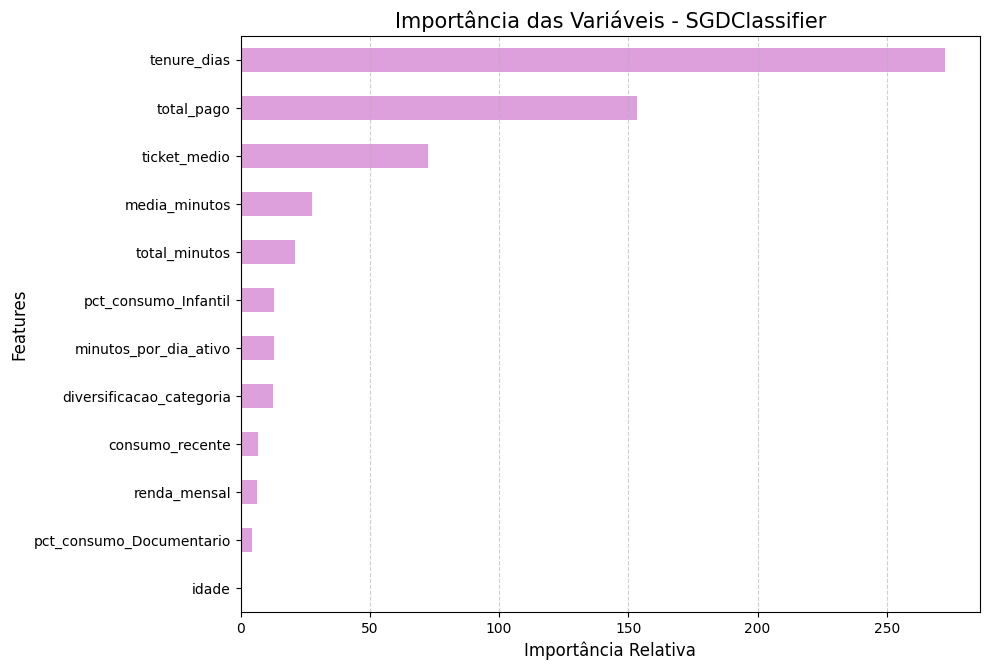


MODELO: XGBClassifier
Acurácia:  0.9933
Recall:    0.9833
F1 Score:  0.9833
Precision: 0.9833


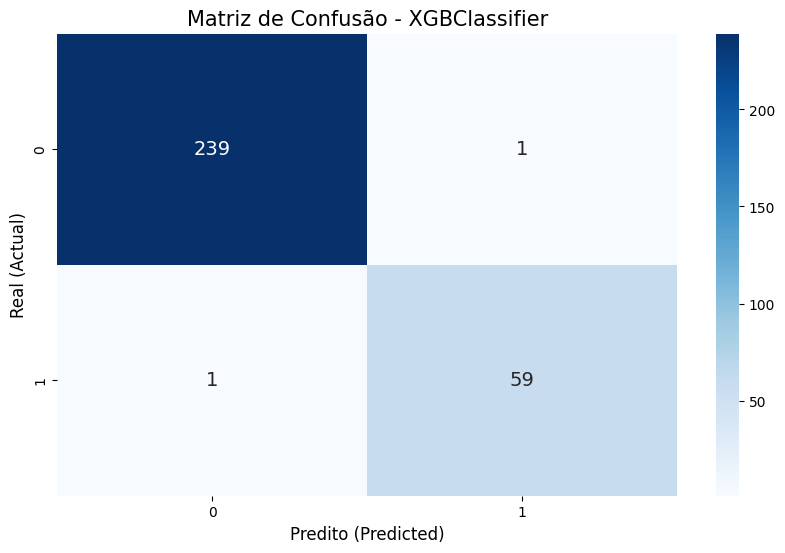

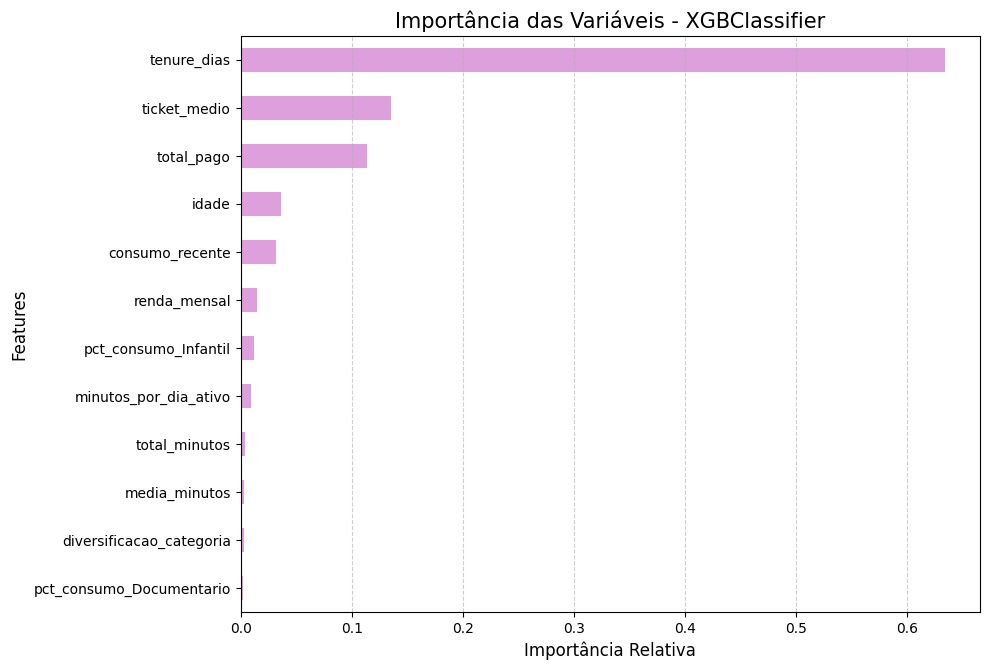

In [91]:
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
knn = KNeighborsClassifier()
nb = GaussianNB()
sgd = SGDClassifier()
xgb = XGBClassifier()

models = [lr, dt, rf, knn, nb, sgd, xgb]
d = {}
# Loop pelos modelos
for i in models:
    # 1. Treino e Predição
    i.fit(X_train, y_train)
    y_pred = i.predict(X_test)
    model_name = i.__class__.__name__

    # Métricas para o dicionário e print
    recall = recall_score(y_test, y_pred)
    d.update({model_name: recall * 100})

    print(f'\n' + '='*30)
    print(f'MODELO: {model_name}')
    print(f'='*30)
    print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")

    # --- GRÁFICO 1: Matriz de Confusão ---
    plt.figure(figsize=(10, 6)) # Tamanho maior para visibilidade
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14})

    plt.title(f'Matriz de Confusão - {model_name}', fontsize=15)
    plt.xlabel('Predito (Predicted)', fontsize=12)
    plt.ylabel('Real (Actual)', fontsize=12)
    plt.show()

    # --- GRÁFICO 2: Feature Importance (Todas as Features) ---
    importances = None
    if hasattr(i, 'feature_importances_'):
        importances = i.feature_importances_
    elif hasattr(i, 'coef_'):
        importances = np.abs(i.coef_[0])

    if importances is not None:
        # Criando DataFrame com todas as features
        feat_importances = pd.Series(importances, index=X_train.columns)

        # Ajustamos a altura da figura baseada no número de features (para não amontoar)
        plt.figure(figsize=(10, len(X_train.columns) * 0.4 + 2))

        feat_importances.sort_values(ascending=True).plot(kind='barh', color='plum')

        plt.title(f'Importância das Variáveis - {model_name}', fontsize=15)
        plt.xlabel('Importância Relativa', fontsize=12)
        plt.ylabel('Features', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Nota: O modelo {model_name} não possui cálculo nativo de importância de features.")

<Figure size 1500x700 with 0 Axes>

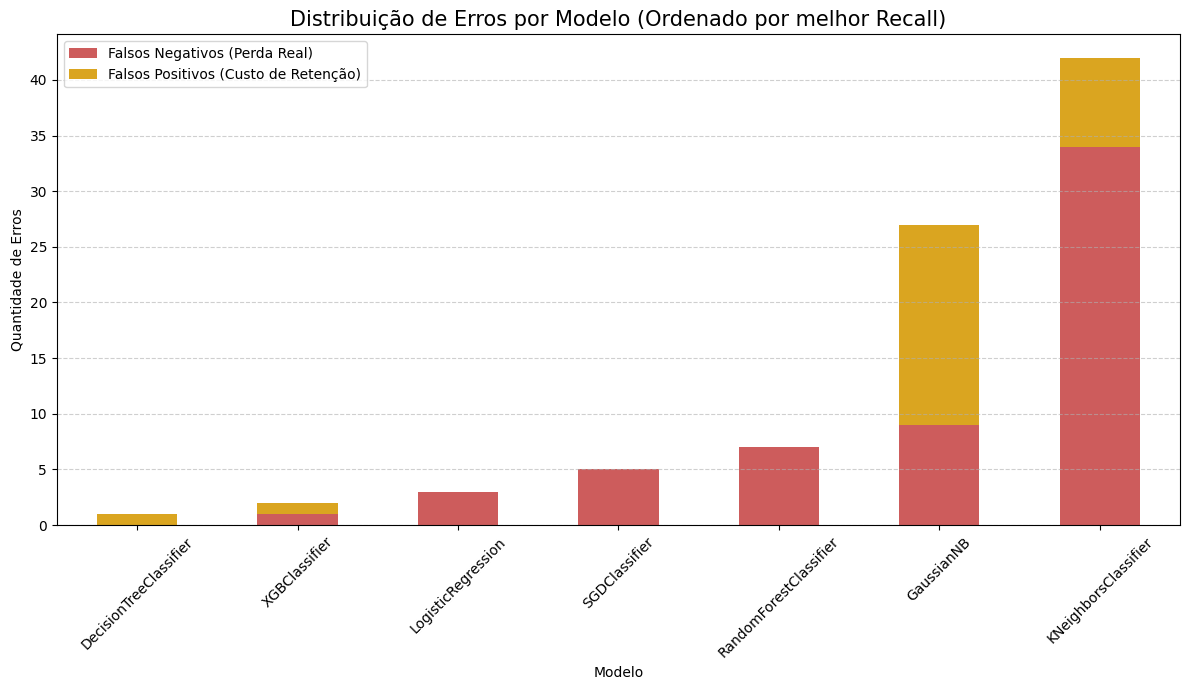

In [92]:
erros_dict = {}

for i in models:
    y_pred = i.predict(X_test)
    model_name = i.__class__.__name__
    cm = confusion_matrix(y_test, y_pred)
    # cm[0,1] = Falsos Positivos (Previu churn, mas era retido)
    # cm[1,0] = Falsos Negativos (Previu retido, mas era churn) - pior
    fp = cm[0, 1]
    fn = cm[1, 0]
    recall = recall_score(y_test, y_pred)
    erros_dict[model_name] = {'FP': fp, 'FN': fn, 'Recall': recall}

# Transformando em DataFrame para ordenar
df_erros = pd.DataFrame(erros_dict).T.sort_values(by='Recall', ascending=False)

plt.figure(figsize=(15, 7))
ax = df_erros[['FN', 'FP']].plot(kind='bar', stacked=True,
                                 figsize=(12, 7), color=['indianred', 'goldenrod'])

plt.title('Distribuição de Erros por Modelo (Ordenado por melhor Recall)', fontsize=15)
plt.xlabel('Modelo')
plt.ylabel('Quantidade de Erros')
plt.legend(['Falsos Negativos (Perda Real)', 'Falsos Positivos (Custo de Retenção)'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Explicação completa item 2 - Treinamento

Realizamos o treinamento com todos os modelos de classificação utilizados em aula. Ao final comparamos os modelos pelos falsos positivos e falsos negativos de cada. O KNN e Gaussian apresentaram os piores resultados, isso pode-se dar devido a forma que eles realizam os calculos (proximidade e distribuição normal). Os melhores modelos foram o XGB e o Decision Tree, com o exato mesmo resultado. Selecionamos o XGB como vencedor.

## 3 - Tuning de Hiperparâmetros
Escolha um algoritmo e faça fine tuning, feature selection e deixe o modelo ajustado, comente a escolha e resultado alcançado

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='recall', # Foco total em reduzir Falsos Negativos
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=1)

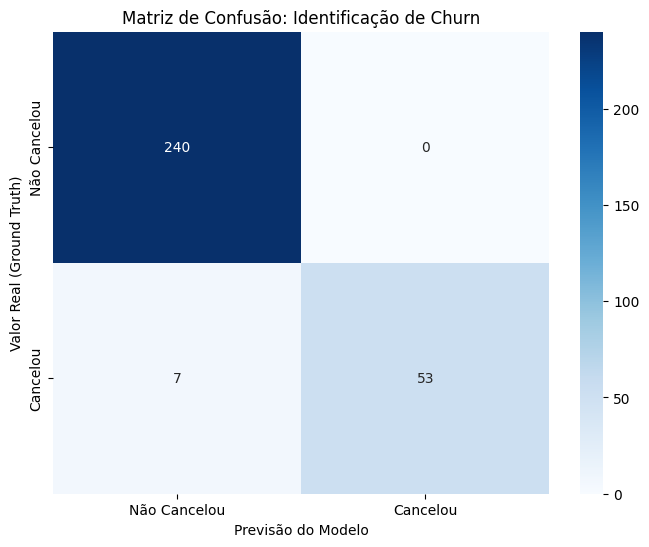


Relatório de Classificação:
              precision    recall  f1-score   support

Não Cancelou       0.97      1.00      0.99       240
    Cancelou       1.00      0.88      0.94        60

    accuracy                           0.98       300
   macro avg       0.99      0.94      0.96       300
weighted avg       0.98      0.98      0.98       300



In [94]:
y_pred = grid_search_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Cancelou', 'Cancelou'],
            yticklabels=['Não Cancelou', 'Cancelou'])
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.title('Matriz de Confusão: Identificação de Churn')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Cancelou', 'Cancelou']))

In [95]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, bootstrap=True)

# Expandimos o espaço de busca
param_dist_rf = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_samples': [0.7, 0.8, 1.0]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_samples': [0.7, 0.8, 1.0],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600]},
                   random_state=42, scoring='recall', verbose=1)

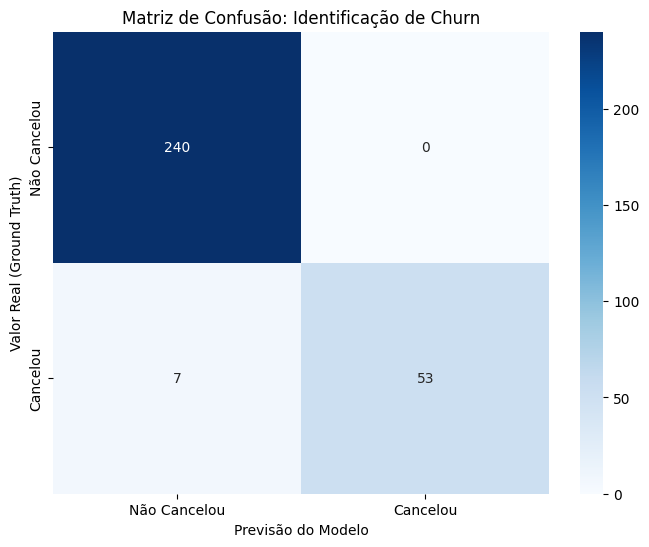


Relatório de Classificação:
              precision    recall  f1-score   support

Não Cancelou       0.97      1.00      0.99       240
    Cancelou       1.00      0.88      0.94        60

    accuracy                           0.98       300
   macro avg       0.99      0.94      0.96       300
weighted avg       0.98      0.98      0.98       300



In [96]:
y_pred = random_search_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Cancelou', 'Cancelou'],
            yticklabels=['Não Cancelou', 'Cancelou'])
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.title('Matriz de Confusão: Identificação de Churn')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Cancelou', 'Cancelou']))

In [97]:
# Em vez de usar .predict(), use .predict_proba()
y_probs = random_search_rf.best_estimator_.predict_proba(X_test)[:, 1]

# Baixe o limiar (ex: 0.3 em vez de 0.5)
# Isso forçará o modelo a classificar mais casos como "Positivo"
y_pred_custom = (y_probs >= 0.3).astype(int)

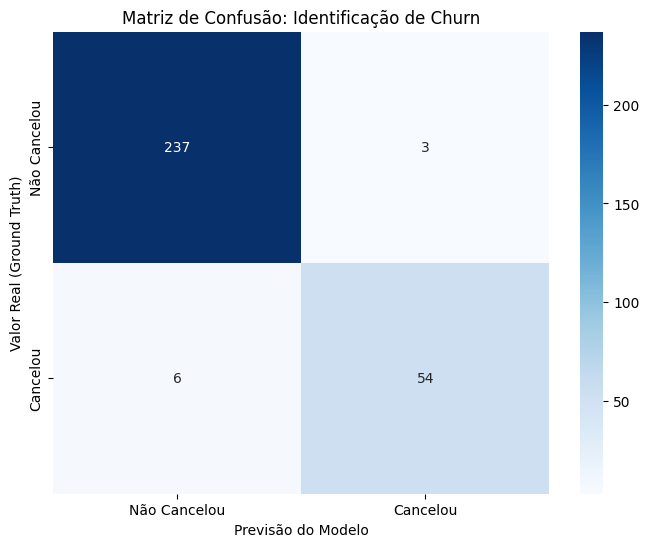


Relatório de Classificação:
              precision    recall  f1-score   support

Não Cancelou       0.97      1.00      0.99       240
    Cancelou       1.00      0.88      0.94        60

    accuracy                           0.98       300
   macro avg       0.99      0.94      0.96       300
weighted avg       0.98      0.98      0.98       300



In [98]:
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Cancelou', 'Cancelou'],
            yticklabels=['Não Cancelou', 'Cancelou'])
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.title('Matriz de Confusão: Identificação de Churn')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Cancelou', 'Cancelou']))

### Explicação completa item 3 - Tuning de Hiperparâmetros

Como tivemos um resultado muito satisfatório com o XGBoost, acabamos optando por fazer o tuning em outro modelo que não performou tão bem, o RandomForest. Nosso foco era enconctrar o melhor recall, pois ele teve um número considerável de falsos negativos.

Primeiro tentamos com o gridsearch, exploramos os hiperparametros de profundidade e número de árvores. Depois fizemos algo parecido, mas usando o randomized search, que não testa todas as possibilidades possiveis, ele faz de uma forma aleatória e vai achando os melhores resultados a cada iteração. No randomized search foram adicionados os hiperparâmetros de tamanho mínimo de folha e número mínimo de registros para a ramificação.

Apesar de nenhum dos dois terem surtido diferença no resultado, deixamos as tentativas registradas.

## 4 - Explicabilidade do Modelo
Aplique ao menos dois gráficos de explicabilidade e explique

In [99]:
# Retreino com os dados despadronizados - para ajudar na explicabilidade
df_features_sem_redundancia_despadronizado = df_numerico_total.drop(columns=to_drop)
df_features_sem_redundancia_despadronizado = df_features_sem_redundancia_despadronizado.drop(["variacao_consumo", "downgrade", "mudanca_plano", "qtd_devices", "min_minutos"], axis=1)
# Separação dados de treino e teste para Embedded Method
X = df_features_sem_redundancia_despadronizado.drop([var_target], axis=1) # Armazena todas as variáveis menos a variável alvo
y = df_features_sem_redundancia_despadronizado[var_target] # armazena apenas a variável alvo
# Dividindo entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


MODELO: XGBClassifier
Acurácia:  0.9933
Recall:    0.9833
F1 Score:  0.9833
Precision: 0.9833


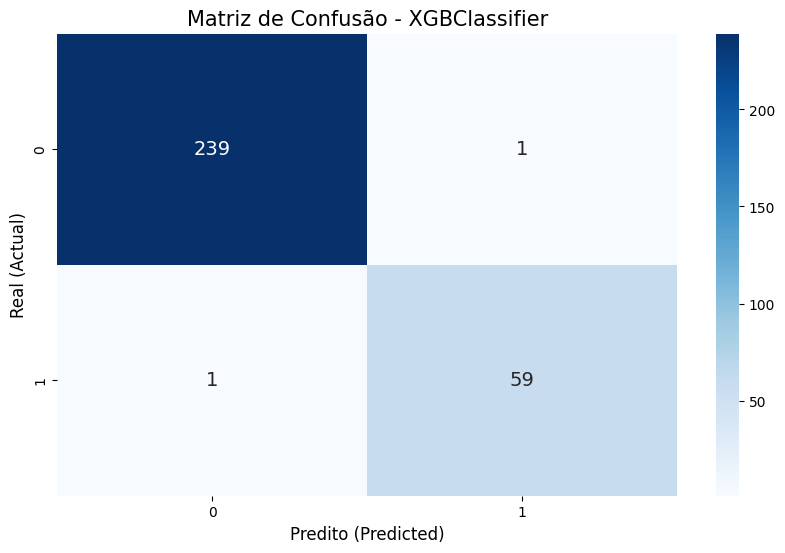

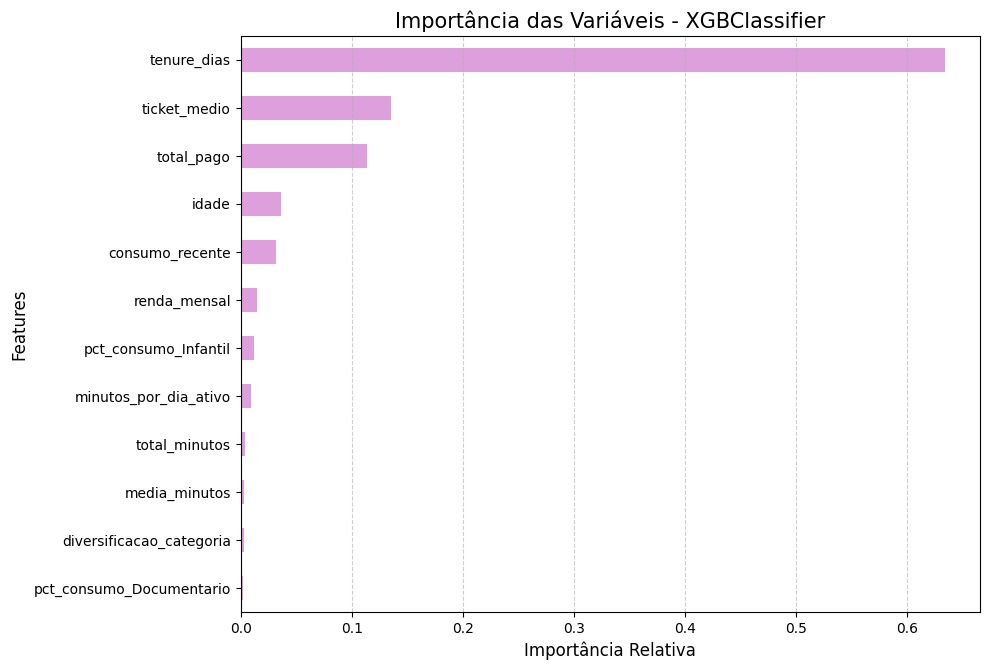

In [100]:
# Treinando XGBClassifier com todas as variáveis e verificando a feature importance de cada
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
model_name = xgb.__class__.__name__

print(f'\n' + '='*30)
print(f'MODELO: {model_name}')
print(f'='*30)
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")

# --- GRÁFICO 1: Matriz de Confusão ---
plt.figure(figsize=(10, 6)) # Tamanho maior para visibilidade
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14})

plt.title(f'Matriz de Confusão - {model_name}', fontsize=15)
plt.xlabel('Predito (Predicted)', fontsize=12)
plt.ylabel('Real (Actual)', fontsize=12)
plt.show()

# --- GRÁFICO 2: Feature Importance (Todas as Features) ---
importances = xgb.feature_importances_

feat_importances = pd.Series(importances, index=X_train.columns)

# Ajustamos a altura da figura baseada no número de features (para não amontoar)
plt.figure(figsize=(10, len(X_train.columns) * 0.4 + 2))

feat_importances.sort_values(ascending=True).plot(kind='barh', color='plum')

plt.title(f'Importância das Variáveis - {model_name}', fontsize=15)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [101]:
!pip install shap --quiet

In [102]:
import shap

In [103]:
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

In [104]:
def plot_shap_explanations(shap_values, X, idx=0, class_idx=1, show_force=True):

    values_shape = shap_values.values.shape
    is_multiclass = len(values_shape) == 3

    if is_multiclass:
        shap_values_global = shap.Explanation(
            values=shap_values.values[:, :, class_idx],
            base_values=shap_values.base_values[:, class_idx],
            data=shap_values.data,
            feature_names=X.columns if hasattr(X, "columns") else None
        )
    else:
        shap_values_global = shap_values

    print("→ Beeswarm")
    shap.plots.beeswarm(shap_values_global, show=True)

    print("→ Bar")
    shap.plots.bar(shap_values_global, show=True)

    if is_multiclass:
        exp = shap.Explanation(
            values=shap_values.values[idx, :, class_idx],
            base_values=shap_values.base_values[idx, class_idx],
            data=shap_values.data[idx],
            feature_names=X.columns if hasattr(X, "columns") else None
        )
    else:
        exp = shap_values[idx]

    print("→ Waterfall")
    shap.plots.waterfall(exp, show=True)

→ Beeswarm


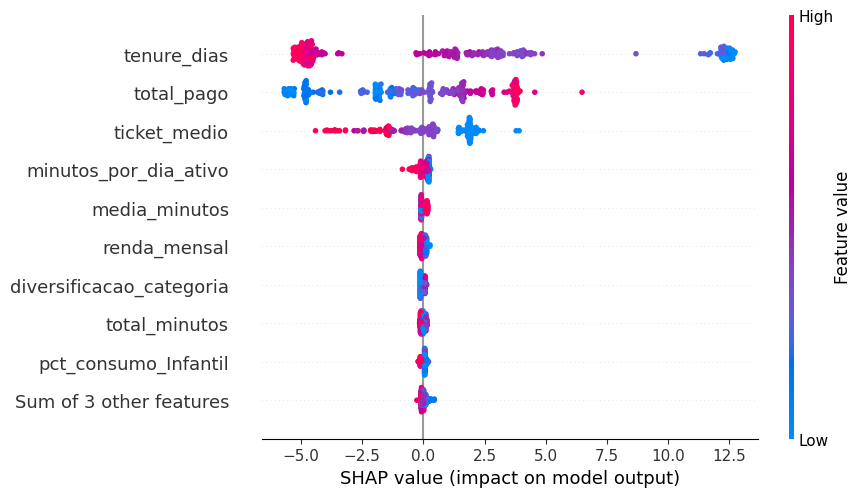

→ Bar


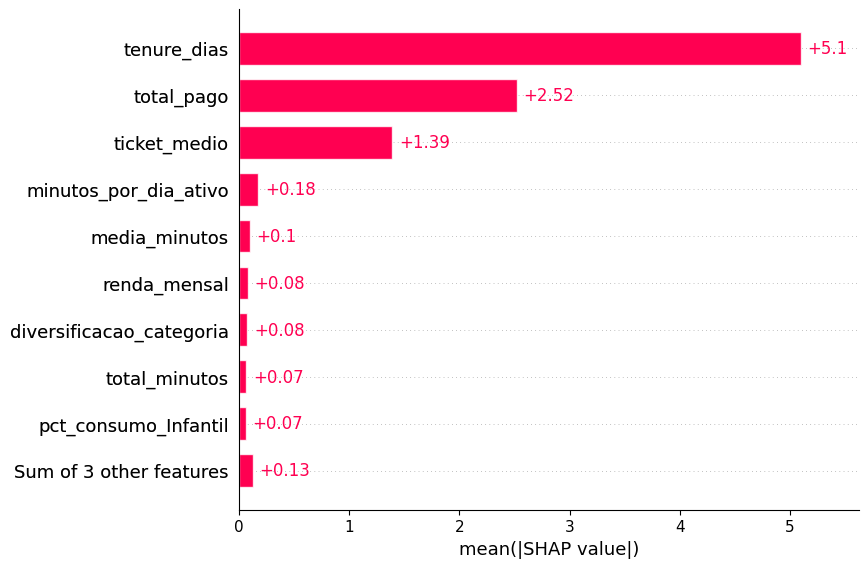

→ Waterfall


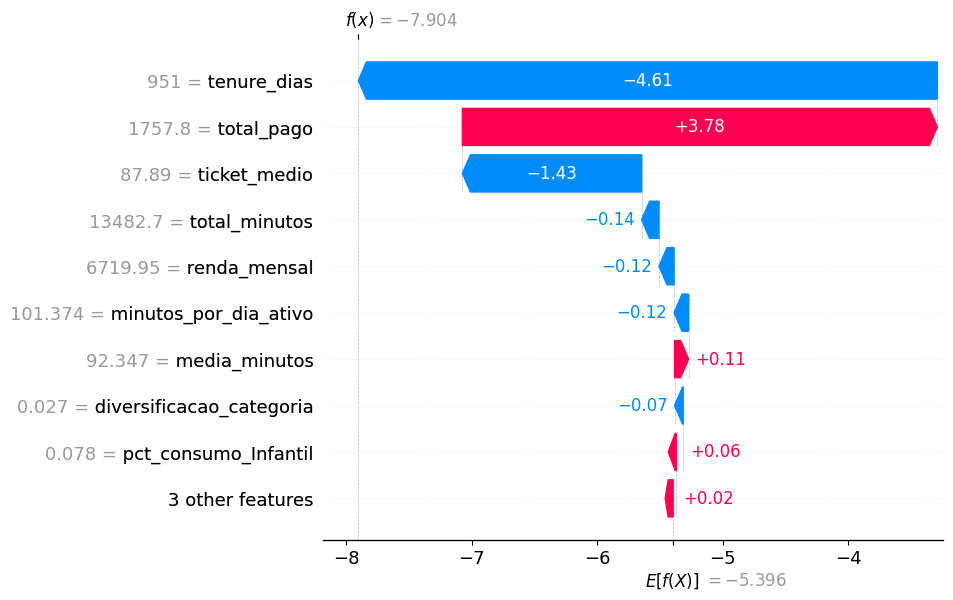

In [105]:
plot_shap_explanations(shap_values, X_test, idx=0, class_idx=1, show_force=True)

#### Explicação completa item 4

Iniciamos refazendo o treinamento do modelo para utilizar as variáveis não padronizadas. Por ser um modelo de árvore, a padronização não era essencial, e inclusie o resultado foi exatamente o mesmo.

Agora sobe os gráficos....

Beeswarm

Esse grafico apresentou quanto o valor de cada variavel influenciou positivamente ou negativamente para o rsultado final.

Bar

Um gráfico de barras simples com a média da importância de cada variável (magnitude absoluta).

Waterfall

Pegou um registro específico e mostrou quanto cada variável afetou no resultado final

Interpretação geral

Quanto mais tempo o cliente fica, menos chance de sair ele tem. Deve existir alguma janela especifica, como "Se ficar após X meses, dificilmente vai sair". Outra relação interessante é o ticket médio, pois quanto maior o tkm, menor a probabilidade dele sair... ou seja, há uma relação entre a retenção e o plano consumido. Após a despadronização ficou um pouco dificil de enxergar as outras variáveis devido a diferença de escala. Entretanto, outra informação relevante é que o tipo de conteúdo assistido também influenciou o modelo. Se a pessoa assistia mais documentário e menos conteúdo infantil, ela tinha maior chance de cancelar... o que pode revelar que o perfil familiar costuma ser mais retido que o perfil de adultos solteiros.


## 5 - Extraindo o modelo para subida em produção

In [106]:
import joblib

joblib.dump(xgb, 'rf_model.pkl')
joblib.dump(xgb, 'rf_model.joblib')

['rf_model.joblib']

In [107]:
import joblib

# Se quiser usar o XGBoost:
joblib.dump(xgb, 'modelo_churn.pkl')

['modelo_churn.pkl']

In [108]:
clientes.head()

,cliente_id,data_adesao,data_cancelamento,plano,idade,renda_mensal
0,1,2022-04-13,NaT,Basic,39.0,7236.90
1,2,2022-08-03,2022-11-28,Basic,38.0,2641.63
2,3,2022-12-10,NaT,Basic,30.0,3568.54
3,4,2022-01-22,2024-06-26,Basic,24.0,5128.49
4,5,2024-02-22,NaT,Standard,35.0,1650.50


In [109]:
features.head()

,cliente_id,data_adesao,data_cancelamento,plano,idade,renda_mensal,churn,data_fim,tenure_dias,total_pago,...,pct_consumo_Serie,diversificacao_categoria,engajamento_score,qtd_devices,device_major,canal,mudanca_plano,downgrade,quartil_renda,plano_ordinal
0,1,2022-04-13,NaT,Basic,39.0,7236.90,0,2025-12-31,1358,971.75,...,0.460085,0.023121,2.078516,1,Desktop,Google,2,0,Q4,1
1,2,2022-08-03,2022-11-28,Basic,38.0,2641.63,1,2022-11-28,117,89.70,...,0.321009,0.024691,2.090593,3,Desktop,Google,2,0,Q1,1
2,3,2022-12-10,NaT,Basic,30.0,3568.54,0,2025-12-31,1117,792.35,...,0.465955,0.050633,2.071220,2,SmartTV,Meta,2,0,Q2,1
3,4,2022-01-22,2024-06-26,Basic,24.0,5128.49,1,2024-06-26,886,852.15,...,0.575620,0.062500,1.824308,3,Desktop,Google,2,0,Q3,1
4,5,2024-02-22,NaT,Standard,35.0,1650.50,0,2025-12-31,678,548.90,...,0.424072,0.037736,2.089962,2,SmartTV,Organico,2,0,Q1,2
